   # Team JM2 Classification Predict Student Solution

© Explore Data Science Academy

---
### Honour Code

We {**TEAM JM2**}, confirm - by submitting this document - that the solutions in this notebook are a result of my own work and that I abide by the [EDSA honour code](https://drive.google.com/file/d/1QDCjGZJ8-FmJE3bZdIQNwnJyQKPhHZBn/view?usp=sharing).

Non-compliance with the honour code constitutes a material breach of contract

### Predict Overview: Climate Change Belief Analysis 2022



Many companies are built around lessening one’s environmental impact or carbon footprint. They offer products and services that are environmentally friendly and sustainable, in line with their values and ideals. They would like to determine how people perceive climate change and whether or not they believe it is a real threat. This would add to their market research efforts in gauging how their product/service may be received.

With this context, EDSA is challenging you during the Classification Sprint with the task of creating a Machine Learning model that is able to classify whether or not a person believes in climate change, based on their novel tweet data.

Providing an accurate and robust solution to this task gives companies access to a broad base of consumer sentiment, spanning multiple demographic and geographic categories - thus increasing their insights and informing future marketing strategies.

<a id="cont"></a>

## Table of Contents

<a href=#one>1. Importing Packages</a>

<a href=#two>2. Loading Data</a>

<a href=#three>3. Pre-processing of the datasets</a>

<a href=#four>4. Exploratory Data Analysis (EDA)</a>

<a href=#five>5. Data Engineering</a>

<a href=#six>6. Modeling</a>

<a href=#seven>7. Model Performance</a>

<a href=#seven>8. Model Explanations</a>
<a href=#seven>9. Conclusion</a>

 <a id="one"></a>
# 1. Importing Packages
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Importing Packages ⚡ |
| :--------------------------- |
| In this section we imported and briefly discussed the libraries that will be used throughout the analysis and modelling. |

---

### 1.1. Data analysis Packages
To analyze the the data we will need the following packages
<ul> 
    <li><b>Numpy</b></li>
    Numpy is a packages used to perform a wide variety of mathematical operations on arrays. It adds powerful data structures to Python that guarantee efficient calculations with arrays and matrices and it supplies an enormous library of high-level mathematical functions that operate on these arrays and matrices.<br>
    <li><b>Pandas</b></li>
    Pandas is mainly used for data analysis and associated manipulation of tabular data in Dataframes. Pandas allows importing data from various file formats such as comma-separated values, JSON, Parquet, SQL database tables or queries, and Microsoft Excel.
    <li><b>Matplotlib</b></li>
    Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It is a cross-platform library for making 2D plots from data in arrays. It provides an object-oriented API that helps in embedding plots in applications using Python GUI toolkits such as PyQt, WxPythonotTkinter.
    <li><b>Seaborn</b></li>
    Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures. Seaborn helps you explore and understand your data.
    <li><b>Wordcloud</b></li>
    A wordcloud is a collection, or cluster, of words depicted in different sizes. The bigger and bolder the word appears, the more often it’s mentioned within a given text and the more important it is.
</ul>

In [378]:
# Libraries for data loading, data manipulation and data visulisation
import pandas as pd      
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
# set plot style
sns.set()

### 1.2. Data Preparation Packages
Before fitting the model to the data it is necessary to do some work on it. THe following packages will help achieve that.

<ul> 
    <li><b>stopwords</b></li>
    Decision trees regression normally use mean squared error (MSE) to decide to split a node in two or more sub-nodes. Suppose we are doing a binary tree the algorithm first will pick a value, and split the data into two subset. For each subset, it will calculate the MSE separately.
    <li><b>tokenizer</b></li>
    A random forest regressor. A random forest is a meta estimator that fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.
    <li><b>WordNetLemmatizer</b></li>
    A voting regressor is an ensemble meta-estimator that fits several base regressors, each on the whole dataset. Then it averages the individual predictions to form a final prediction.
    <li><b>CountVectorizer</b></li>
    Stacked generalization consists in stacking the output of individual estimator and use a regressor to compute the final prediction. 
    <li><b>PorterStemmer</b></li>
    A Bagging regressor is an ensemble meta-estimator that fits base regressors each on random subsets of the original dataset and then aggregate their individual predictions (either by voting or by averaging) to form a final prediction.
    <li><b>SVM</b></li>
    Support vector machines (SVMs) are a set of supervised learning methods used for classification, regression and outliers detection. The advantages of support vector machines are: Effective in high dimensional spaces. Still effective in cases where number of dimensions is greater than the number of samples.
    <li><b>Seaborn</b></li>
    Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures. Seaborn helps you explore and understand your data.
</ul>

In [379]:
import nltk   #Importing nltk
from nltk.corpus import stopwords  #importing Stopwords
import string
from nltk.tokenize import word_tokenize, TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from nltk import SnowballStemmer, PorterStemmer, LancasterStemmer
import pickle

### 1.3. Data Engineering Packages


In [380]:
from sklearn.utils import resample
from nltk.util import ngrams
from imblearn.over_sampling import SMOTE 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder

### 1.4. Machine Learning Packages
To analyze the data we will need the following packages
<ul> 
    <li><b>train_test_split</b></li> train_test_split is a model validation procedure that allows you to simulate how a model would perform on new/unseen data.
    <li><b>LogisticRegression</b></li> Logistic regression is a statistical analysis method to predict a binary outcome, such as yes or no, based on prior observations of a data set.
    <li><b>DecisionTreeClassifier</b></li> DecisionTreeClassifier is a class capable of performing multi-class classification on a dataset.
    <li><b>XGBClassifier</b></li> XGBoost, which stands for Extreme Gradient Boosting, is a scalable, distributed gradient-boosted decision tree (GBDT) machine learning library. It provides parallel tree boosting and is the leading machine learning library for regression, classification, and ranking problems.
    <li><b>CatBoostClassifier</b></li> CatBoost is an algorithm for gradient boosting on decision trees. It is developed by Yandex researchers and engineers, and is used for search, recommendation systems, personal assistant, self-driving cars, weather prediction and many other tasks at Yandex and in other companies, including CERN, Cloudflare, Careem taxi. It is in open-source and can be used by anyone. The CatBoost library can be used to solve both classification and regression challenge.
    <li><b>VotingClassifier</b></li> A voting classifier is a machine learning estimator that trains various base models or estimators and predicts on the basis of aggregating the findings of each base estimator.
</ul>

In [381]:
# Libraries for data preparation and model building
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

# Model performance metric libraries
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import classification_report

### 1.4. Other Packages
To analyze the the data we will need the following packages
<ul> 
    <li><b>Pickle</b></li>
    Pickle in Python is primarily used in serializing and deserializing a Python object structure. In other words, it's the process of converting a Python object into a byte stream to store it in a file/database, maintain program state across sessions, or transport data over the network.
    <li><b>Metrics</b></li>
    The sklearn. metrics module implements several loss, score, and utility functions to measure classification performance. Some metrics might require probability estimates of the positive class, confidence values, or binary decisions values.
    <li><b>Os</b></li>
    The OS module in Python provides functions for interacting with the operating system. OS comes under Python's standard utility modules. This module provides a portable way of using operating system-dependent functionality.
    <li><b>Math</b></li>
    For straightforward mathematical calculations in Python, you can use the built-in mathematical operators, such as addition ( + ), subtraction ( - ), division ( / ), and multiplication ( * ). But more advanced operations, such as exponential, logarithmic, trigonometric, or power functions, are not built in.
</ul>

## Comet

Comet is connected onto this notebook in order to monitor and store metrics, notebook and models. 

In [456]:
#Importing comet library
from comet_ml import Experiment

# Creating an experiment on comet with the api key
experiment = Experiment(
    api_key="GcTv9Oug0ZRsTdoU4iwKxuWPC",
    project_name="edsa-climate-change-sentiment-analysis",
    workspace="emmantheo",
)

COMET WARNING: Comet has disabled auto-logging functionality as it has been imported after the following ML modules: sklearn, xgboost. Metrics and hyperparameters can still be logged using comet_ml.log_metrics() and comet_ml.log_parameters()
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.ml https://www.comet.ml/emmantheo/edsa-climate-change-sentiment-analysis/0746a07997e2477096929168e57602bd



<a id="two"></a>
# 2. Loading the Data
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Loading the data ⚡ |
| :--------------------------- |
| In this section we are going to load the data from the `train` and  `test_with_no_labels` file into DataFrames. |

---

For the pupose of the model development, two datasets have been provided in two csv files
<ul>
<li><b>Train Data Set</b></li>
Training data is an extremely large dataset that is used to teach a machine learning model. Training data is used to teach prediction models that use machine learning algorithms how to extract features that are relevant to specific business goals.
<li><b>Test Data Set</b></li>
Test data is data which has been specifically identified for use in tests, typically of a computer program. Some data may be used in a confirmatory way, typically to verify that a given set of input to a given function produces some expected result.
</ul>

We will load these datasets in two data frames so we can use them for the model development. After loading the data, we will display the head of the dataset to get the first idea of the type of data we are working with.


In [383]:
#Loading the train dataset
df_train = pd.read_csv('train.csv')
df_train.head(20)

,sentiment,message,tweetid
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221
1,1,It's not like we lack evidence of anthropogeni...,126103
2,2,RT @RawStory: Researchers say we have three ye...,698562
3,1,#TodayinMaker# WIRED : 2016 was a pivotal year...,573736
4,1,"RT @SoyNovioDeTodas: It's 2016, and a racist, ...",466954
5,1,Worth a read whether you do or don't believe i...,425577
6,1,RT @thenation: Mike Pence doesn’t believe in g...,294933
7,1,RT @makeandmendlife: Six big things we can ALL...,992717
8,1,@AceofSpadesHQ My 8yo nephew is inconsolable. ...,664510
9,1,RT @paigetweedy: no offense… but like… how do ...,260471


From the trained data, it can be observed that we are dealing with text and numeric data. The label is numeric where;

2 represents news about climate change

1 represents belief in climate change

0 represents neutral belief

-1 represents unbelief

In [384]:
#checking the number of rows and column in our train dataset. 
df_train.shape

(15819, 3)

The train data contains 15819 rows while there is 3 columns in in which we are dropping the third column which represents ID of twitter users. This is because we do not need the ID column.

In [385]:
#Loading the test dataset
df_test = pd.read_csv('test.csv')
df_test.head(20)

,message,tweetid
0,Europe will now be looking to China to make su...,169760
1,Combine this with the polling of staffers re c...,35326
2,"The scary, unimpeachable evidence that climate...",224985
3,@Karoli @morgfair @OsborneInk @dailykos \r\nPu...,476263
4,RT @FakeWillMoore: 'Female orgasms cause globa...,872928
5,RT @nycjim: Trump muzzles employees of several...,75639
6,@bmastenbrook yes wrote that in 3rd yr Comp Sc...,211536
7,RT @climatehawk1: Indonesian farmers weather #...,569434
8,RT @guardian: British scientists face a ‘huge ...,315368
9,Aid For Agriculture | Sustainable agriculture ...,591733


From the test data, it can be observed that we are dealing with text and numeric data. Unlike the train data, there is no label column here because that is what we are going to be predicting.

In [386]:
df_test.shape

(10546, 2)

The test data contains 10546 rows while there are 2 columns in which we are dropping the second column which represents ID of twitter users. This is because we do not need the ID column.

<a id="three"></a>
# 3. Pre-processing of the datasets
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Pre-processing of the datasets ⚡ |
| :--------------------------- |
| In this section we are going to perform thorough cleaning of the dataset. Since it is text data, we are going to use the Natural Language Processor (NLP) for this pre-process phase.

---


## TRAIN DATASET PREPROCESSING

Before training our model on the given data, we need to make sure the data is clean enough for use. This is because our model is only as good as the data we feed it. Therefore, the first cleaning of the datasets is going to be done on the train dataset then the unseen test data with the use of Natural Language Processor(NLP).

In [387]:
#Increasing the size of the dataset by separating each of the message in the message column of each row into its own row
all_train = []
for i, row in df_train.iterrows():
    for message in row['message'].split('|||'):
        all_train.append([row['sentiment'], message])
all_train = pd.DataFrame(all_train, columns=['sentiment', 'message'])

In [388]:
#checking to see if the column has been dropped
all_train.shape

(15820, 2)

The tweet ID column was successfully dropped leaving us with only the sentiment(label) and message(feature) columns for our training to be carried out.

In [389]:
#Removing noise from the train dataset
pattern_url = r'http[s]?://(?:[A-Za-z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9A-Fa-f][0-9A-Fa-f]))+'
subs_url = r'url-web'
all_train['message'] = all_train['message'].replace(to_replace = pattern_url, value = subs_url, regex = True)

Noises such as symbols, special characters and web links which are called noises were successfully removed from the data in order to make the data clean. 

In [390]:
#checking the train dataset to see if the noise were removed
all_train.head(20)

,sentiment,message
0,1,PolySciMajor EPA chief doesn't think carbon di...
1,1,It's not like we lack evidence of anthropogeni...
2,2,RT @RawStory: Researchers say we have three ye...
3,1,#TodayinMaker# WIRED : 2016 was a pivotal year...
4,1,"RT @SoyNovioDeTodas: It's 2016, and a racist, ..."
5,1,Worth a read whether you do or don't believe i...
6,1,RT @thenation: Mike Pence doesn’t believe in g...
7,1,RT @makeandmendlife: Six big things we can ALL...
8,1,@AceofSpadesHQ My 8yo nephew is inconsolable. ...
9,1,RT @paigetweedy: no offense… but like… how do ...


In [391]:
#converting all train text to lower case 
all_train['message'] = all_train['message'].str.lower()

Conversion of the text data to lowercase was carried out in order to ensure uniform cleaning of the data. 

In [392]:
#function for removing punctuation
def remove_punctuation(message):
    return ''.join([j for j in message if j not in string.punctuation])

A function for removal of punctuation was created in order to help remove punctuations. This function is also going to be applied on the test data also.

In [393]:
#Removing punctuation from train dataset
all_train['message'] = all_train['message'].apply(remove_punctuation)

In [394]:
#Checking if punctuation from the train dataset has been removed
all_train['message'].iloc[20]

'rt c40cities 46 c40 mayors representing 250m citizens have urged g20 leaders to saveourplanet from climate change you can too…'

Punctuations were removed from the train data. We go ahead to tokenise the text. The tokeniser divides text into a sequence of tokens, which roughly correspond to "words". We will use tokenisers to clean up the data, making it ready for prediction.

In [395]:
#Initialising the tokeniser
tokeniser = TreebankWordTokenizer()

tokenised_tweet = all_train['message'].apply(lambda x: x.split()) #Tokenising the train data

In [396]:
all_train['tokens'] = tokenised_tweet

In [397]:
#checking to see if text is tokenised
all_train['tokens'].iloc[4]

['rt',
 'soynoviodetodas',
 'its',
 '2016',
 'and',
 'a',
 'racist',
 'sexist',
 'climate',
 'change',
 'denying',
 'bigot',
 'is',
 'leading',
 'in',
 'the',
 'polls',
 'electionnight']

In [312]:
#creating function for removing stop words for both the train and test data
def remove_stop_words(tokens):    
    return [t for t in tokens if t not in stopwords.words('english')]

In [313]:
%%time
#removing stopwords from the train data
all_train['tokens'] = all_train['tokens'].apply(remove_stop_words)

Wall time: 2min 24s


In [315]:
#checking to see if stopwords have been removed
all_train['tokens']

0        [polyscimajor, epa, chief, doesnt, think, carb...
1        [like, lack, evidence, anthropogenic, global, ...
2        [rt, rawstory, researchers, say, three, years,...
3        [todayinmaker, wired, 2016, pivotal, year, war...
4        [rt, soynoviodetodas, 2016, racist, sexist, cl...
                               ...                        
15815    [rt, ezlusztig, took, material, global, warmin...
15816    [rt, washingtonpost, climate, change, could, b...
15817    [notiven, rt, nytimesworld, trump, actually, b...
15818    [rt, sara8smiles, hey, liberals, climate, chan...
15819    [rt, chetcannon, kurteichenwalds, climate, cha...
Name: tokens, Length: 15820, dtype: object

In [398]:
tokenised_tweet = all_train['tokens']

In [399]:
tokenised_tweet

0        [polyscimajor, epa, chief, doesnt, think, carb...
1        [its, not, like, we, lack, evidence, of, anthr...
2        [rt, rawstory, researchers, say, we, have, thr...
3        [todayinmaker, wired, 2016, was, a, pivotal, y...
4        [rt, soynoviodetodas, its, 2016, and, a, racis...
                               ...                        
15815    [rt, ezlusztig, they, took, down, the, materia...
15816    [rt, washingtonpost, how, climate, change, cou...
15817    [notiven, rt, nytimesworld, what, does, trump,...
15818    [rt, sara8smiles, hey, liberals, the, climate,...
15819    [rt, chetcannon, kurteichenwalds, climate, cha...
Name: tokens, Length: 15820, dtype: object

In [400]:
#Stemming the words from the train data
stemmatized_tweet = tokenised_tweet.apply(lambda sentence: [stemmer.stem(word) for word in sentence])

In [401]:
stemmatized_tweet

0        [polyscimajor, epa, chief, doesnt, think, carb...
1        [it, not, like, we, lack, evid, of, anthropoge...
2        [rt, rawstori, research, say, we, have, three,...
3        [todayinmak, wire, 2016, wa, a, pivot, year, i...
4        [rt, soynoviodetoda, it, 2016, and, a, racist,...
                               ...                        
15815    [rt, ezlusztig, they, took, down, the, materi,...
15816    [rt, washingtonpost, how, climat, chang, could...
15817    [notiven, rt, nytimesworld, what, doe, trump, ...
15818    [rt, sara8smil, hey, liber, the, climat, chang...
15819    [rt, chetcannon, kurteichenwald, climat, chang...
Name: tokens, Length: 15820, dtype: object

In [402]:
#Lemmatizing the train data
lemmatized_tweet = stemmatized_tweet.apply(lambda sentence: [lemmatizer.lemmatize(word) for word in sentence])
lemmatized_tweet.head() #Checking to see if Lemmatized

0    [polyscimajor, epa, chief, doesnt, think, carb...
1    [it, not, like, we, lack, evid, of, anthropoge...
2    [rt, rawstori, research, say, we, have, three,...
3    [todayinmak, wire, 2016, wa, a, pivot, year, i...
4    [rt, soynoviodetoda, it, 2016, and, a, racist,...
Name: tokens, dtype: object

In [403]:
#combining the cleaned message column into single sentence for the train dataset
for i in range(len(lemmatized_tweet)):
    lemmatized_tweet[i] = " ".join(lemmatized_tweet[i])
all_train['cleaned_tweet'] = lemmatized_tweet

In [404]:
#checking to see if well combined into sentence
all_train.head() 

,sentiment,message,tokens,cleaned_tweet
0,1,polyscimajor epa chief doesnt think carbon dio...,"[polyscimajor, epa, chief, doesnt, think, carb...",polyscimajor epa chief doesnt think carbon dio...
1,1,its not like we lack evidence of anthropogenic...,"[its, not, like, we, lack, evidence, of, anthr...",it not like we lack evid of anthropogen global...
2,2,rt rawstory researchers say we have three year...,"[rt, rawstory, researchers, say, we, have, thr...",rt rawstori research say we have three year to...
3,1,todayinmaker wired 2016 was a pivotal year in...,"[todayinmaker, wired, 2016, was, a, pivotal, y...",todayinmak wire 2016 wa a pivot year in the wa...
4,1,rt soynoviodetodas its 2016 and a racist sexis...,"[rt, soynoviodetodas, its, 2016, and, a, racis...",rt soynoviodetoda it 2016 and a racist sexist ...


## TEST DATASET PREPROCESSING

In [405]:
#Removing noise from the test dataset
pattern_url = r'http[s]?://(?:[A-Za-z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9A-Fa-f][0-9A-Fa-f]))+'
subs_url = r'url-web'
df_test['message'] = df_test['message'].replace(to_replace = pattern_url, value = subs_url, regex = True)

In [406]:
#checking the train dataset to see if the noise were removed
df_test.head(20)

,message,tweetid
0,Europe will now be looking to China to make su...,169760
1,Combine this with the polling of staffers re c...,35326
2,"The scary, unimpeachable evidence that climate...",224985
3,@Karoli @morgfair @OsborneInk @dailykos \r\nPu...,476263
4,RT @FakeWillMoore: 'Female orgasms cause globa...,872928
5,RT @nycjim: Trump muzzles employees of several...,75639
6,@bmastenbrook yes wrote that in 3rd yr Comp Sc...,211536
7,RT @climatehawk1: Indonesian farmers weather #...,569434
8,RT @guardian: British scientists face a ‘huge ...,315368
9,Aid For Agriculture | Sustainable agriculture ...,591733


In [407]:
#converting all test text to lower case 
df_test['message'] = df_test['message'].str.lower()

In [408]:
#Removing punctuation from test dataset
df_test['message'] = df_test['message'].apply(remove_punctuation)

In [409]:
#Checking if punctuation from the test dataset has been removed
df_test['message'].iloc[4]

'rt fakewillmoore female orgasms cause global warming\r\nsarcastic republican'

In [410]:
#Tokenising the test data
tokenised_tweet_test = df_test['message'].apply(lambda x: x.split()) 

In [411]:
df_test['tokens'] = tokenised_tweet_test

In [412]:
df_test['tokens'].iloc[4]

['rt',
 'fakewillmoore',
 'female',
 'orgasms',
 'cause',
 'global',
 'warming',
 'sarcastic',
 'republican']

In [331]:
# Removing stopwords from the test data
df_test['tokens'] = df_test['tokens'].apply(remove_stop_words)

In [332]:
df_test['tokens']

0        [europe, looking, china, make, sure, alone, fi...
1        [combine, polling, staffers, climate, change, ...
2        [scary, unimpeachable, evidence, climate, chan...
3        [karoli, morgfair, osborneink, dailykos, putin...
4        [rt, fakewillmoore, female, orgasms, cause, gl...
                               ...                        
10541    [rt, brittanybohrer, brb, writing, poem, clima...
10542    [2016, year, climate, change, came, home, hott...
10543    [rt, loopvanuatu, pacific, countries, positive...
10544    [rt, xanria00018, you’re, hot, must, cause, gl...
10545    [rt, chloebalaoing, climate, change, global, i...
Name: tokens, Length: 10546, dtype: object

In [413]:
tokenised_tweet_test = df_test['tokens']

In [414]:
#stemming the words from the test data
stemmatized_tweet_test = tokenised_tweet_test.apply(lambda sentence: [stemmer.stem(word) for word in sentence])

In [415]:
stemmatized_tweet_test

0        [europ, will, now, be, look, to, china, to, ma...
1        [combin, thi, with, the, poll, of, staffer, re...
2        [the, scari, unimpeach, evid, that, climat, ch...
3        [karoli, morgfair, osborneink, dailyko, putin,...
4        [rt, fakewillmoor, femal, orgasm, caus, global...
                               ...                        
10541    [rt, brittanybohr, brb, write, a, poem, about,...
10542    [2016, the, year, climat, chang, came, home, d...
10543    [rt, loopvanuatu, pacif, countri, posit, about...
10544    [rt, xanria00018, you’r, so, hot, you, must, b...
10545    [rt, chloebalao, climat, chang, is, a, global,...
Name: tokens, Length: 10546, dtype: object

In [416]:
#Lemmatizing the test data
lemmatized_tweet_test = stemmatized_tweet_test.apply(lambda sentence: [lemmatizer.lemmatize(word) for word in sentence])
lemmatized_tweet_test.head()

0    [europ, will, now, be, look, to, china, to, ma...
1    [combin, thi, with, the, poll, of, staffer, re...
2    [the, scari, unimpeach, evid, that, climat, ch...
3    [karoli, morgfair, osborneink, dailyko, putin,...
4    [rt, fakewillmoor, femal, orgasm, caus, global...
Name: tokens, dtype: object

In [417]:
#combining the cleaned message column into single sentence for the test dataset
for j in range(len(lemmatized_tweet_test)):
    lemmatized_tweet_test[j] = " ".join(lemmatized_tweet_test[j])
df_test['cleaned_tweet'] = lemmatized_tweet_test

In [418]:
df_test.head() #checking to see if well combined into sentence

,message,tweetid,tokens,cleaned_tweet
0,europe will now be looking to china to make su...,169760,"[europe, will, now, be, looking, to, china, to...",europ will now be look to china to make sure t...
1,combine this with the polling of staffers re c...,35326,"[combine, this, with, the, polling, of, staffe...",combin thi with the poll of staffer re climat ...
2,the scary unimpeachable evidence that climate ...,224985,"[the, scary, unimpeachable, evidence, that, cl...",the scari unimpeach evid that climat chang is ...
3,karoli morgfair osborneink dailykos \r\nputin ...,476263,"[karoli, morgfair, osborneink, dailykos, putin...",karoli morgfair osborneink dailyko putin got t...
4,rt fakewillmoore female orgasms cause global w...,872928,"[rt, fakewillmoore, female, orgasms, cause, gl...",rt fakewillmoor femal orgasm caus global warm ...


## EXPLORATORY DATA ANALYSIS

In this section we are going to perform an in-depth analysis of all the variables in the DataFrame. This would give us proper knowledge of our predictor variables to know if they are useful in this project.

In [419]:
#checking to see the list of label
sentiment_labels = list(df_train.sentiment.unique())
sentiment_labels

[1, 2, 0, -1]

There are four classes in the label, which shows this is a classification machine learning problem.

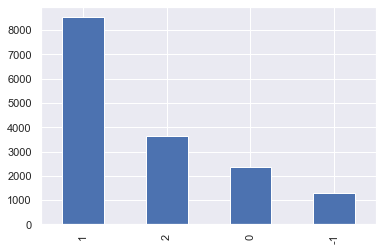

In [420]:
#distribution of the classes in the label
df_train['sentiment'].value_counts().plot(kind = 'bar')
plt.show()

From the distribution, it can be seen that the classes in label are imbalanced.Therefore, to avoid the prediction from being biased, we are going to balance the classes.

In [421]:
# Separate minority and majority classes
neutral = df_train[df_train['sentiment']==0]
believe = df_train[df_train['sentiment']==1]
not_believe = df_train[df_train['sentiment']== -1]
news = df_train[df_train['sentiment']== 2]

In [422]:
#checking the percentage of people who believe in climate change
believe_percent = len(believe)/ (len(neutral)+len(believe)+len(not_believe)+len(news))
believe_percent

0.5392249826158417

In [423]:
#checking the percentage of people who do not believe in climate change
not_believe_percent = len(not_believe)/ (len(neutral)+len(believe)+len(not_believe)+len(news))
not_believe_percent

0.08192679688981605

In [424]:
#checking the percentage of people who are indifferent about climate change
neutral = len(neutral)/ (len(neutral)+len(believe)+len(not_believe)+len(news))
neutral

0.1487451798470194

From the above analysis, we can see that the classes in our ressponse variable is not balanced. Therefore we need to balance it during the Data Engineering part of our work.

## VISUALS

In [425]:
## visualising the frequent words
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet']])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

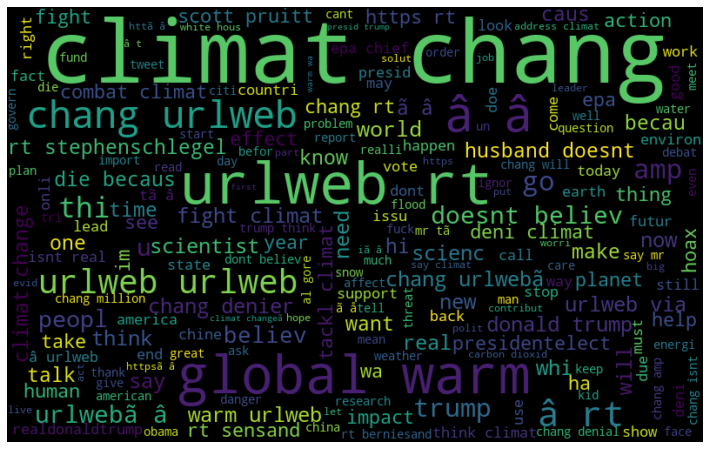

In [426]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Frequent Words used by believers of climate change

In [427]:
##for frequent words in belief of climate change
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet'][all_train['sentiment']==1]])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

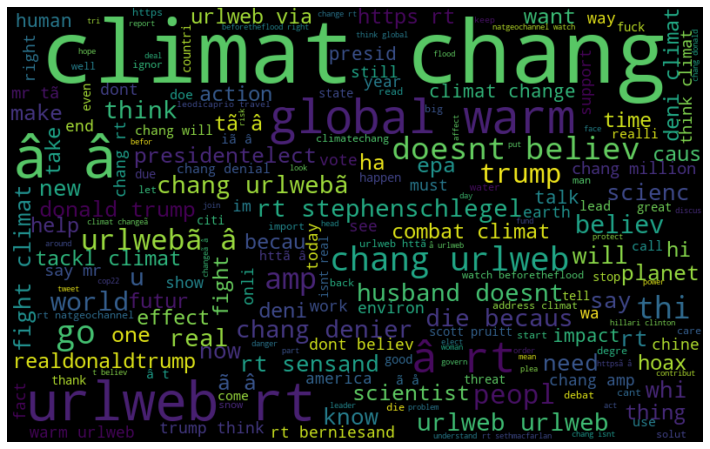

In [428]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Frequent words used by unbelievers of Climate Change

In [429]:
##for frequent words not in belief of climate change
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet'][all_train['sentiment']==-1]])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

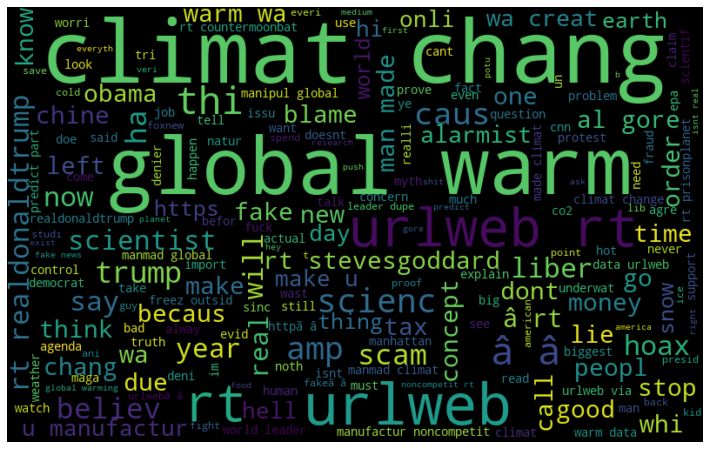

In [430]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Frequent neutral words

In [431]:
##for frequent words of neutrals of climate change
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet'][all_train['sentiment']==0]])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

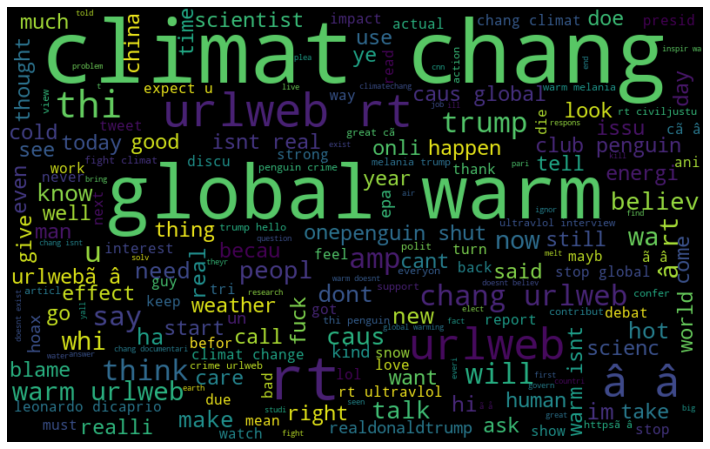

In [432]:
## Ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [433]:
##for frequent words for news of climate change
all_words = " ".join([sentence for sentence in all_train['cleaned_tweet'][all_train['sentiment']==2]])
wordcloud = WordCloud(width= 800, height = 500, random_state= 42, max_font_size= 100).generate(all_words)

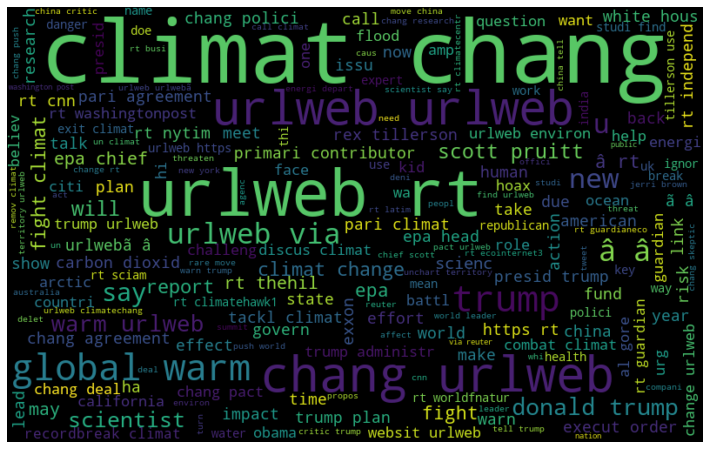

In [434]:
## ploting the graph
plt.figure(figsize = (15, 8))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

<a id="four"></a>
# 4. Data Engineering
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Data engineering ⚡ |
| :--------------------------- |
| In this section we are going to: clean the dataset, and possibly create new features - as identified in the EDA phase. This is the phase where we drop the features we identified to drop in the EDA phase|
---

In [435]:
#Transforming the cleaned text from the trained data
cv = CountVectorizer(max_features= 10000, ngram_range=(1,2))
bow = cv.fit_transform(all_train['cleaned_tweet'])

In [269]:
model_save_path = "countvectoriser.pkl"
with open(model_save_path,'wb') as file:
    pickle.dump(cv,file)

In [436]:
#Transforming the cleaned text from the test data
bow_test = cv.transform(df_test['cleaned_tweet'])

In [437]:
#Converting our data
X = bow
X

<15820x10000 sparse matrix of type '<class 'numpy.int64'>'
	with 366206 stored elements in Compressed Sparse Row format>

In [438]:
y = all_train['sentiment']

In [439]:
smt = SMOTE(random_state = 1, k_neighbors = 1)

In [440]:
X,y = smt.fit_resample(X, y)

In [441]:
y.value_counts()

 0    8530
 1    8530
 2    8530
-1    8530
Name: sentiment, dtype: int64

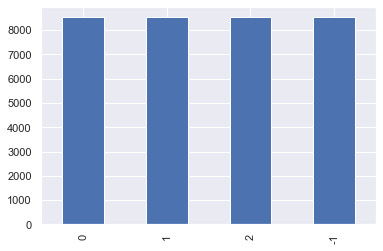

In [442]:
y.value_counts().plot(kind = 'bar')
plt.show()

<a id="five"></a>
# 5. Modelling
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a> 

---

    
| ⚡ Description: Modelling ⚡ |
| :--------------------------- |
| In this section, we created regression models that are able to accurately predict the three hour load shortfall. |

---

In [443]:
#train-test split
x_train, x_test, y_train, y_test = train_test_split(X, y, 
random_state = 42, test_size = 0.25)

### 5.1. Logistic Regression Model

In [279]:
#Model Training using logistic regression
#model = LogisticRegression(multi_class='ovr')
model = LogisticRegression(random_state=42, solver='lbfgs', multi_class='multinomial', C=0.1, penalty='l2')
model.fit(x_train, y_train)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=0.1, multi_class='multinomial', random_state=42)

In [280]:
#Testing
pred = model.predict(x_test)

In [281]:
#Predicting the unseen data
model.fit(X, y)
pred_test = model.predict(bow_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [282]:
result_model = pd.DataFrame(pred_test, columns= ['sentiment'])
result_model.head(20)

,sentiment
0,1
1,1
2,1
3,1
4,0
5,2
6,1
7,1
8,2
9,1


In [283]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission = output.join(result_model)
submission.to_csv("submission.csv", index = False)

### 5.2. CatBoost Classification Model

In [364]:
#Model Training using catboost model classifier
catbst = CatBoostClassifier(
                          bootstrap_type="Bernoulli",
                          class_weights=[1, 1, 1, 1],
                          loss_function='MultiClass')

In [365]:
catbst.fit(x_train, y_train)

Learning rate set to 0.093354
0:	learn: 1.3368899	total: 261ms	remaining: 4m 20s
1:	learn: 1.2985820	total: 421ms	remaining: 3m 30s
2:	learn: 1.2676562	total: 595ms	remaining: 3m 17s
3:	learn: 1.2404831	total: 756ms	remaining: 3m 8s
4:	learn: 1.2179881	total: 909ms	remaining: 3m
5:	learn: 1.1975113	total: 1.06s	remaining: 2m 55s
6:	learn: 1.1802261	total: 1.23s	remaining: 2m 55s
7:	learn: 1.1644668	total: 1.38s	remaining: 2m 51s
8:	learn: 1.1519760	total: 1.52s	remaining: 2m 47s
9:	learn: 1.1414114	total: 1.65s	remaining: 2m 42s
10:	learn: 1.1311279	total: 1.78s	remaining: 2m 39s
11:	learn: 1.1224575	total: 2s	remaining: 2m 44s
12:	learn: 1.1141913	total: 2.12s	remaining: 2m 41s
13:	learn: 1.1085353	total: 2.25s	remaining: 2m 38s
14:	learn: 1.1031260	total: 2.37s	remaining: 2m 35s
15:	learn: 1.0973371	total: 2.5s	remaining: 2m 34s
16:	learn: 1.0909603	total: 2.63s	remaining: 2m 32s
17:	learn: 1.0865153	total: 2.79s	remaining: 2m 32s
18:	learn: 1.0826677	total: 2.91s	remaining: 2m 30s
1

160:	learn: 0.8803115	total: 20.2s	remaining: 1m 45s
161:	learn: 0.8794833	total: 20.3s	remaining: 1m 44s
162:	learn: 0.8787728	total: 20.4s	remaining: 1m 44s
163:	learn: 0.8780618	total: 20.5s	remaining: 1m 44s
164:	learn: 0.8775252	total: 20.6s	remaining: 1m 44s
165:	learn: 0.8768595	total: 20.6s	remaining: 1m 43s
166:	learn: 0.8761388	total: 20.8s	remaining: 1m 43s
167:	learn: 0.8752941	total: 20.9s	remaining: 1m 43s
168:	learn: 0.8745360	total: 21s	remaining: 1m 43s
169:	learn: 0.8737011	total: 21.1s	remaining: 1m 43s
170:	learn: 0.8730105	total: 21.2s	remaining: 1m 42s
171:	learn: 0.8722728	total: 21.3s	remaining: 1m 42s
172:	learn: 0.8716297	total: 21.4s	remaining: 1m 42s
173:	learn: 0.8709346	total: 21.5s	remaining: 1m 42s
174:	learn: 0.8697126	total: 21.6s	remaining: 1m 41s
175:	learn: 0.8690632	total: 21.7s	remaining: 1m 41s
176:	learn: 0.8681307	total: 21.8s	remaining: 1m 41s
177:	learn: 0.8673397	total: 21.9s	remaining: 1m 41s
178:	learn: 0.8663018	total: 22s	remaining: 1m 4

317:	learn: 0.7968163	total: 37.9s	remaining: 1m 21s
318:	learn: 0.7965254	total: 38s	remaining: 1m 21s
319:	learn: 0.7963272	total: 38.1s	remaining: 1m 20s
320:	learn: 0.7959759	total: 38.2s	remaining: 1m 20s
321:	learn: 0.7955915	total: 38.4s	remaining: 1m 20s
322:	learn: 0.7953054	total: 38.5s	remaining: 1m 20s
323:	learn: 0.7948945	total: 38.6s	remaining: 1m 20s
324:	learn: 0.7946780	total: 38.7s	remaining: 1m 20s
325:	learn: 0.7940825	total: 38.8s	remaining: 1m 20s
326:	learn: 0.7939114	total: 39s	remaining: 1m 20s
327:	learn: 0.7936357	total: 39.1s	remaining: 1m 20s
328:	learn: 0.7933845	total: 39.2s	remaining: 1m 19s
329:	learn: 0.7930543	total: 39.3s	remaining: 1m 19s
330:	learn: 0.7926901	total: 39.4s	remaining: 1m 19s
331:	learn: 0.7923473	total: 39.5s	remaining: 1m 19s
332:	learn: 0.7918679	total: 39.6s	remaining: 1m 19s
333:	learn: 0.7916232	total: 39.8s	remaining: 1m 19s
334:	learn: 0.7914100	total: 39.9s	remaining: 1m 19s
335:	learn: 0.7910113	total: 40s	remaining: 1m 18s

476:	learn: 0.7493412	total: 55s	remaining: 1m
477:	learn: 0.7490620	total: 55.1s	remaining: 1m
478:	learn: 0.7487100	total: 55.2s	remaining: 1m
479:	learn: 0.7483413	total: 55.4s	remaining: 60s
480:	learn: 0.7482246	total: 55.5s	remaining: 59.8s
481:	learn: 0.7479214	total: 55.6s	remaining: 59.7s
482:	learn: 0.7476883	total: 55.7s	remaining: 59.6s
483:	learn: 0.7475424	total: 55.8s	remaining: 59.5s
484:	learn: 0.7472456	total: 55.9s	remaining: 59.3s
485:	learn: 0.7467441	total: 56s	remaining: 59.2s
486:	learn: 0.7465721	total: 56.1s	remaining: 59.1s
487:	learn: 0.7464202	total: 56.2s	remaining: 58.9s
488:	learn: 0.7461362	total: 56.3s	remaining: 58.8s
489:	learn: 0.7457985	total: 56.4s	remaining: 58.7s
490:	learn: 0.7455155	total: 56.5s	remaining: 58.5s
491:	learn: 0.7452423	total: 56.6s	remaining: 58.4s
492:	learn: 0.7449128	total: 56.7s	remaining: 58.3s
493:	learn: 0.7447110	total: 56.8s	remaining: 58.1s
494:	learn: 0.7445334	total: 56.9s	remaining: 58s
495:	learn: 0.7443511	total: 

638:	learn: 0.7156022	total: 1m 11s	remaining: 40.3s
639:	learn: 0.7155074	total: 1m 11s	remaining: 40.1s
640:	learn: 0.7152795	total: 1m 11s	remaining: 40s
641:	learn: 0.7152165	total: 1m 11s	remaining: 39.9s
642:	learn: 0.7150934	total: 1m 11s	remaining: 39.8s
643:	learn: 0.7149798	total: 1m 11s	remaining: 39.7s
644:	learn: 0.7149023	total: 1m 11s	remaining: 39.6s
645:	learn: 0.7147491	total: 1m 12s	remaining: 39.5s
646:	learn: 0.7145957	total: 1m 12s	remaining: 39.3s
647:	learn: 0.7144707	total: 1m 12s	remaining: 39.2s
648:	learn: 0.7144011	total: 1m 12s	remaining: 39.1s
649:	learn: 0.7141771	total: 1m 12s	remaining: 39s
650:	learn: 0.7140599	total: 1m 12s	remaining: 38.9s
651:	learn: 0.7139840	total: 1m 12s	remaining: 38.7s
652:	learn: 0.7138124	total: 1m 12s	remaining: 38.6s
653:	learn: 0.7136238	total: 1m 12s	remaining: 38.5s
654:	learn: 0.7130640	total: 1m 12s	remaining: 38.4s
655:	learn: 0.7129146	total: 1m 13s	remaining: 38.3s
656:	learn: 0.7128335	total: 1m 13s	remaining: 38.

795:	learn: 0.6909569	total: 1m 29s	remaining: 22.9s
796:	learn: 0.6908905	total: 1m 29s	remaining: 22.8s
797:	learn: 0.6907933	total: 1m 29s	remaining: 22.7s
798:	learn: 0.6902926	total: 1m 29s	remaining: 22.5s
799:	learn: 0.6900524	total: 1m 29s	remaining: 22.4s
800:	learn: 0.6898929	total: 1m 29s	remaining: 22.3s
801:	learn: 0.6896605	total: 1m 29s	remaining: 22.2s
802:	learn: 0.6895796	total: 1m 29s	remaining: 22.1s
803:	learn: 0.6893962	total: 1m 30s	remaining: 21.9s
804:	learn: 0.6893455	total: 1m 30s	remaining: 21.8s
805:	learn: 0.6892153	total: 1m 30s	remaining: 21.7s
806:	learn: 0.6891498	total: 1m 30s	remaining: 21.6s
807:	learn: 0.6890483	total: 1m 30s	remaining: 21.5s
808:	learn: 0.6890003	total: 1m 30s	remaining: 21.4s
809:	learn: 0.6888750	total: 1m 30s	remaining: 21.3s
810:	learn: 0.6887365	total: 1m 30s	remaining: 21.1s
811:	learn: 0.6885085	total: 1m 30s	remaining: 21s
812:	learn: 0.6883065	total: 1m 30s	remaining: 20.9s
813:	learn: 0.6881202	total: 1m 30s	remaining: 2

951:	learn: 0.6702216	total: 1m 45s	remaining: 5.33s
952:	learn: 0.6700913	total: 1m 45s	remaining: 5.22s
953:	learn: 0.6700110	total: 1m 45s	remaining: 5.11s
954:	learn: 0.6699020	total: 1m 46s	remaining: 5s
955:	learn: 0.6697580	total: 1m 46s	remaining: 4.89s
956:	learn: 0.6695423	total: 1m 46s	remaining: 4.78s
957:	learn: 0.6694150	total: 1m 46s	remaining: 4.67s
958:	learn: 0.6692266	total: 1m 46s	remaining: 4.56s
959:	learn: 0.6690224	total: 1m 46s	remaining: 4.45s
960:	learn: 0.6687718	total: 1m 46s	remaining: 4.34s
961:	learn: 0.6686085	total: 1m 47s	remaining: 4.23s
962:	learn: 0.6685384	total: 1m 47s	remaining: 4.12s
963:	learn: 0.6684602	total: 1m 47s	remaining: 4s
964:	learn: 0.6683661	total: 1m 47s	remaining: 3.89s
965:	learn: 0.6683306	total: 1m 47s	remaining: 3.78s
966:	learn: 0.6682665	total: 1m 47s	remaining: 3.67s
967:	learn: 0.6682231	total: 1m 47s	remaining: 3.56s
968:	learn: 0.6680773	total: 1m 47s	remaining: 3.45s
969:	learn: 0.6679614	total: 1m 47s	remaining: 3.34s

In [367]:
#Testing
y_pred = catbst.predict(x_test)

In [368]:
catbst.fit(X, y)

Learning rate set to 0.094734
0:	learn: 1.3403665	total: 121ms	remaining: 2m
1:	learn: 1.2991207	total: 244ms	remaining: 2m 1s
2:	learn: 1.2662489	total: 415ms	remaining: 2m 17s
3:	learn: 1.2379543	total: 547ms	remaining: 2m 16s
4:	learn: 1.2136294	total: 693ms	remaining: 2m 17s
5:	learn: 1.1935983	total: 852ms	remaining: 2m 21s
6:	learn: 1.1759091	total: 1s	remaining: 2m 22s
7:	learn: 1.1612506	total: 1.14s	remaining: 2m 21s
8:	learn: 1.1486834	total: 1.28s	remaining: 2m 21s
9:	learn: 1.1373001	total: 1.41s	remaining: 2m 19s
10:	learn: 1.1284309	total: 1.55s	remaining: 2m 19s
11:	learn: 1.1192123	total: 1.69s	remaining: 2m 19s
12:	learn: 1.1111472	total: 1.83s	remaining: 2m 18s
13:	learn: 1.1034534	total: 1.97s	remaining: 2m 18s
14:	learn: 1.0976565	total: 2.11s	remaining: 2m 18s
15:	learn: 1.0920700	total: 2.21s	remaining: 2m 16s
16:	learn: 1.0872860	total: 2.33s	remaining: 2m 14s
17:	learn: 1.0824981	total: 2.45s	remaining: 2m 13s
18:	learn: 1.0778911	total: 2.56s	remaining: 2m 12s


158:	learn: 0.8748700	total: 21.6s	remaining: 1m 54s
159:	learn: 0.8740835	total: 21.7s	remaining: 1m 54s
160:	learn: 0.8734030	total: 21.9s	remaining: 1m 54s
161:	learn: 0.8727623	total: 22.1s	remaining: 1m 54s
162:	learn: 0.8718958	total: 22.2s	remaining: 1m 53s
163:	learn: 0.8712222	total: 22.3s	remaining: 1m 53s
164:	learn: 0.8704261	total: 22.5s	remaining: 1m 53s
165:	learn: 0.8698698	total: 22.6s	remaining: 1m 53s
166:	learn: 0.8692697	total: 22.8s	remaining: 1m 53s
167:	learn: 0.8683710	total: 22.9s	remaining: 1m 53s
168:	learn: 0.8677718	total: 23s	remaining: 1m 53s
169:	learn: 0.8669720	total: 23.2s	remaining: 1m 53s
170:	learn: 0.8658954	total: 23.3s	remaining: 1m 53s
171:	learn: 0.8653161	total: 23.5s	remaining: 1m 52s
172:	learn: 0.8647249	total: 23.6s	remaining: 1m 52s
173:	learn: 0.8639386	total: 23.7s	remaining: 1m 52s
174:	learn: 0.8630525	total: 23.9s	remaining: 1m 52s
175:	learn: 0.8621127	total: 24s	remaining: 1m 52s
176:	learn: 0.8611369	total: 24.2s	remaining: 1m 5

315:	learn: 0.7923697	total: 43.4s	remaining: 1m 33s
316:	learn: 0.7920393	total: 43.5s	remaining: 1m 33s
317:	learn: 0.7916402	total: 43.7s	remaining: 1m 33s
318:	learn: 0.7912515	total: 43.8s	remaining: 1m 33s
319:	learn: 0.7909866	total: 43.9s	remaining: 1m 33s
320:	learn: 0.7907882	total: 44s	remaining: 1m 33s
321:	learn: 0.7904544	total: 44.1s	remaining: 1m 32s
322:	learn: 0.7902073	total: 44.2s	remaining: 1m 32s
323:	learn: 0.7898550	total: 44.3s	remaining: 1m 32s
324:	learn: 0.7894980	total: 44.5s	remaining: 1m 32s
325:	learn: 0.7891101	total: 44.6s	remaining: 1m 32s
326:	learn: 0.7886904	total: 44.7s	remaining: 1m 32s
327:	learn: 0.7884151	total: 44.8s	remaining: 1m 31s
328:	learn: 0.7881222	total: 44.9s	remaining: 1m 31s
329:	learn: 0.7877689	total: 45s	remaining: 1m 31s
330:	learn: 0.7874343	total: 45.2s	remaining: 1m 31s
331:	learn: 0.7871954	total: 45.3s	remaining: 1m 31s
332:	learn: 0.7867834	total: 45.4s	remaining: 1m 30s
333:	learn: 0.7864043	total: 45.5s	remaining: 1m 3

471:	learn: 0.7451547	total: 1m 2s	remaining: 1m 9s
472:	learn: 0.7448206	total: 1m 2s	remaining: 1m 9s
473:	learn: 0.7444781	total: 1m 2s	remaining: 1m 9s
474:	learn: 0.7443606	total: 1m 2s	remaining: 1m 9s
475:	learn: 0.7441175	total: 1m 2s	remaining: 1m 8s
476:	learn: 0.7439385	total: 1m 2s	remaining: 1m 8s
477:	learn: 0.7438112	total: 1m 2s	remaining: 1m 8s
478:	learn: 0.7436602	total: 1m 3s	remaining: 1m 8s
479:	learn: 0.7433100	total: 1m 3s	remaining: 1m 8s
480:	learn: 0.7429689	total: 1m 3s	remaining: 1m 8s
481:	learn: 0.7426290	total: 1m 3s	remaining: 1m 8s
482:	learn: 0.7424627	total: 1m 3s	remaining: 1m 8s
483:	learn: 0.7423555	total: 1m 3s	remaining: 1m 7s
484:	learn: 0.7420706	total: 1m 3s	remaining: 1m 7s
485:	learn: 0.7419411	total: 1m 3s	remaining: 1m 7s
486:	learn: 0.7417378	total: 1m 4s	remaining: 1m 7s
487:	learn: 0.7415395	total: 1m 4s	remaining: 1m 7s
488:	learn: 0.7413797	total: 1m 4s	remaining: 1m 7s
489:	learn: 0.7412553	total: 1m 4s	remaining: 1m 7s
490:	learn: 

629:	learn: 0.7110510	total: 1m 22s	remaining: 48.3s
630:	learn: 0.7108279	total: 1m 22s	remaining: 48.2s
631:	learn: 0.7107208	total: 1m 22s	remaining: 48.1s
632:	learn: 0.7105337	total: 1m 22s	remaining: 48s
633:	learn: 0.7104600	total: 1m 22s	remaining: 47.9s
634:	learn: 0.7101593	total: 1m 23s	remaining: 47.7s
635:	learn: 0.7099088	total: 1m 23s	remaining: 47.6s
636:	learn: 0.7097477	total: 1m 23s	remaining: 47.5s
637:	learn: 0.7096556	total: 1m 23s	remaining: 47.4s
638:	learn: 0.7095642	total: 1m 23s	remaining: 47.2s
639:	learn: 0.7093375	total: 1m 23s	remaining: 47.1s
640:	learn: 0.7090186	total: 1m 23s	remaining: 47s
641:	learn: 0.7088076	total: 1m 24s	remaining: 46.9s
642:	learn: 0.7086612	total: 1m 24s	remaining: 46.7s
643:	learn: 0.7085531	total: 1m 24s	remaining: 46.6s
644:	learn: 0.7083632	total: 1m 24s	remaining: 46.5s
645:	learn: 0.7082580	total: 1m 24s	remaining: 46.4s
646:	learn: 0.7081868	total: 1m 24s	remaining: 46.3s
647:	learn: 0.7081194	total: 1m 24s	remaining: 46.

786:	learn: 0.6879895	total: 1m 44s	remaining: 28.2s
787:	learn: 0.6879052	total: 1m 44s	remaining: 28.1s
788:	learn: 0.6877083	total: 1m 44s	remaining: 27.9s
789:	learn: 0.6876370	total: 1m 44s	remaining: 27.8s
790:	learn: 0.6875162	total: 1m 44s	remaining: 27.7s
791:	learn: 0.6873359	total: 1m 44s	remaining: 27.6s
792:	learn: 0.6870419	total: 1m 45s	remaining: 27.4s
793:	learn: 0.6868352	total: 1m 45s	remaining: 27.3s
794:	learn: 0.6866799	total: 1m 45s	remaining: 27.2s
795:	learn: 0.6863924	total: 1m 45s	remaining: 27s
796:	learn: 0.6862075	total: 1m 45s	remaining: 26.9s
797:	learn: 0.6861327	total: 1m 45s	remaining: 26.8s
798:	learn: 0.6860191	total: 1m 45s	remaining: 26.6s
799:	learn: 0.6859593	total: 1m 46s	remaining: 26.5s
800:	learn: 0.6857492	total: 1m 46s	remaining: 26.4s
801:	learn: 0.6856110	total: 1m 46s	remaining: 26.2s
802:	learn: 0.6854402	total: 1m 46s	remaining: 26.1s
803:	learn: 0.6852714	total: 1m 46s	remaining: 26s
804:	learn: 0.6852097	total: 1m 46s	remaining: 25.

943:	learn: 0.6678135	total: 2m 9s	remaining: 7.68s
944:	learn: 0.6676909	total: 2m 9s	remaining: 7.54s
945:	learn: 0.6675914	total: 2m 9s	remaining: 7.41s
946:	learn: 0.6674824	total: 2m 9s	remaining: 7.27s
947:	learn: 0.6673442	total: 2m 9s	remaining: 7.13s
948:	learn: 0.6672567	total: 2m 10s	remaining: 6.99s
949:	learn: 0.6670054	total: 2m 10s	remaining: 6.86s
950:	learn: 0.6667835	total: 2m 10s	remaining: 6.72s
951:	learn: 0.6666091	total: 2m 10s	remaining: 6.58s
952:	learn: 0.6665426	total: 2m 10s	remaining: 6.45s
953:	learn: 0.6664379	total: 2m 10s	remaining: 6.31s
954:	learn: 0.6663069	total: 2m 10s	remaining: 6.17s
955:	learn: 0.6661878	total: 2m 11s	remaining: 6.04s
956:	learn: 0.6660122	total: 2m 11s	remaining: 5.9s
957:	learn: 0.6659072	total: 2m 11s	remaining: 5.76s
958:	learn: 0.6658746	total: 2m 11s	remaining: 5.62s
959:	learn: 0.6658084	total: 2m 11s	remaining: 5.49s
960:	learn: 0.6657284	total: 2m 11s	remaining: 5.35s
961:	learn: 0.6656988	total: 2m 11s	remaining: 5.21s

In [369]:
y_pred_test = catbst.predict(bow_test)

In [370]:
result_cat = pd.DataFrame(y_pred_test, columns= ['sentiment'])
result_cat.head(20)

,sentiment
0,1
1,0
2,1
3,1
4,0
5,1
6,1
7,1
8,2
9,1


In [371]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_cat = output.join(result_model)
submission_cat.to_csv("submission_cat.csv", index = False)

### 5.3. Decision Tree Classification Model

In [457]:
#Classification
tree = DecisionTreeClassifier(random_state=42)

In [458]:
tree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [459]:
tree_pred = tree.predict(x_test)

In [460]:
tree.fit(X, y)

DecisionTreeClassifier(random_state=42)

In [461]:
tree_pred_test = tree.predict(bow_test)

In [462]:
result_tree = pd.DataFrame(tree_pred_test, columns= ['sentiment'])
result_tree.head(20)

,sentiment
0,1
1,0
2,1
3,1
4,0
5,1
6,0
7,2
8,2
9,1


In [463]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_tree = output.join(result_tree)
submission_tree.to_csv("submission_tree.csv", index = False)

### 5.4. Support Vector Machine

In [444]:
svc = SVC(kernel='rbf')
svc.fit(x_train, y_train)

SVC()

In [445]:
svc_pred = svc.predict(x_test)

In [446]:
svc.fit(X,y)
svc_pred_test = svc.predict(bow_test)

In [447]:
result_svc = pd.DataFrame(svc_pred_test, columns= ['sentiment'])
result_svc.head(20)

,sentiment
0,1
1,1
2,1
3,1
4,0
5,1
6,1
7,1
8,2
9,1


In [448]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_svc = output.join(result_svc)
submission_svc.to_csv("submission_svc.csv", index = False)

In [449]:
model_save_path = "svc_model.pkl"
with open(model_save_path,'wb') as file:
    pickle.dump(svc,file)

### 5.5. Voting Ensemble Classification Model

In [97]:
model_ensemble = VotingClassifier(estimators=[('lr', model), ('dt', tree), ("svm", svc)], voting='hard')

In [98]:
model_ensemble.fit(x_train,y_train)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VotingClassifier(estimators=[('lr',
                              LogisticRegression(multi_class='multinomial',
                                                 random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('svm', SVC())])

In [99]:
ensmb_pred = model_ensemble.predict(x_test)

In [100]:
model_ensemble.fit(x_train,y_train)
esmb_pred_test = model_ensemble.predict(bow_test)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
result_esmb = pd.DataFrame(esmb_pred_test, columns= ['sentiment'])
result_esmb.head(20)

,sentiment
0,1
1,0
2,1
3,1
4,0
5,1
6,1
7,1
8,2
9,1


In [102]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_esmb = output.join(result_esmb)
submission_esmb.to_csv("submission_esmb.csv", index = False)

### 5.6. XGBOOST Classification Model

In [103]:
# fit model no training data
model_xgb = XGBClassifier()
model_xgb.fit(x_train, y_train)

XGBClassifier(objective='multi:softprob')

In [104]:
xgb_pred = model_xgb.predict(x_test)

In [105]:
model_xgb.fit(x_train,y_train)
xgb_pred_test = model_xgb.predict(bow_test)

In [106]:
result_xgb = pd.DataFrame(xgb_pred_test, columns= ['sentiment'])
result_xgb.head(20)

,sentiment
0,1
1,2
2,2
3,1
4,0
5,2
6,1
7,2
8,2
9,2


In [107]:
output = pd.DataFrame({"tweetid":df_test['tweetid']})
submission_xgb = output.join(result_xgb)
submission_xgb.to_csv("submission_xgb.csv", index = False)

<a id="six"></a>
# 6. Model Performance
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Model performance ⚡ |
| :--------------------------- |
| In this section the relative performance of the various trained ML models on a holdout dataset was carried out. 
---

## 6.1. Classification Report

In [450]:
#Creating function for checking model performance
def get_class_report(y_test, y_predict):
    #your code here
    accuracy = classification_report(y_test, y_predict)
    return accuracy

#### 6.11. Logistic Regression Classification Report

In [285]:
#Checking Logistics Regression model performance
print(get_class_report(y_test, pred))

              precision    recall  f1-score   support

          -1       0.74      0.67      0.70      2092
           0       0.64      0.70      0.67      2102
           1       0.81      0.79      0.80      2132
           2       0.84      0.86      0.85      2204

    accuracy                           0.76      8530
   macro avg       0.76      0.76      0.76      8530
weighted avg       0.76      0.76      0.76      8530



#### 6.12. Catboost Classification Report

In [373]:
#Checking Catboost Classification model performance
print(get_class_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.70      0.72      0.71      2092
           0       0.66      0.57      0.61      2102
           1       0.79      0.74      0.76      2132
           2       0.73      0.85      0.79      2204

    accuracy                           0.72      8530
   macro avg       0.72      0.72      0.72      8530
weighted avg       0.72      0.72      0.72      8530



#### 6.13. Decision Tree Classification Report

In [464]:
#Checking Decision Tree Classification model performance
print(get_class_report(y_test, tree_pred))

              precision    recall  f1-score   support

          -1       0.76      0.85      0.80      2092
           0       0.75      0.70      0.73      2102
           1       0.74      0.67      0.70      2132
           2       0.80      0.83      0.81      2204

    accuracy                           0.76      8530
   macro avg       0.76      0.76      0.76      8530
weighted avg       0.76      0.76      0.76      8530



#### 6.14. Support Vector Machine Classification Report

In [451]:
#Checking Support Vector Machine Classification model performance
print(get_class_report(y_test, svc_pred))

              precision    recall  f1-score   support

          -1       0.79      0.80      0.80      2092
           0       0.81      0.66      0.73      2102
           1       0.75      0.88      0.81      2132
           2       0.86      0.85      0.86      2204

    accuracy                           0.80      8530
   macro avg       0.80      0.80      0.80      8530
weighted avg       0.80      0.80      0.80      8530



#### 6.15. Voting Ensemble Classification Report

In [113]:
#Checking voting ensemble classification model performance
print(get_class_report(y_test, ensmb_pred))

              precision    recall  f1-score   support

          -1       0.75      0.81      0.78      2092
           0       0.74      0.68      0.71      2102
           1       0.79      0.82      0.81      2132
           2       0.86      0.82      0.84      2204

    accuracy                           0.78      8530
   macro avg       0.78      0.78      0.78      8530
weighted avg       0.78      0.78      0.78      8530



#### 6.16. XGBOOST Classification

In [114]:
#Checking xgboost classification model performance
print(get_class_report(y_test, xgb_pred))

              precision    recall  f1-score   support

          -1       0.87      0.67      0.76      2092
           0       0.59      0.57      0.58      2102
           1       0.65      0.60      0.63      2132
           2       0.65      0.87      0.75      2204

    accuracy                           0.68      8530
   macro avg       0.69      0.68      0.68      8530
weighted avg       0.69      0.68      0.68      8530



## 6.2. Saving Model Performance to Comet

#### 6.21. Logistic Regression Model Performance

In [288]:
# Saving each metric to add to a dictionary for logging
f1 = f1_score(y_test, pred, pos_label='positive', average='micro')
precision = precision_score(y_test, pred, pos_label='positive', average='micro')
recall = recall_score(y_test, pred, pos_label='positive', average='micro')

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [289]:
# Create dictionaries for the data we want to log

params = {"random_state": 42,
          "model_type": "logreg",
          "scaler": "standard scaler",
          "stratify": True
          }
metrics = {"f1": f1,
           "recall": recall,
           "precision": precision
           }

In [290]:
# Log our parameters and results
experiment.log_parameters(params)
experiment.log_metrics(metrics)

In [291]:
experiment.end()

COMET INFO: ---------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.ml/emmantheo/edsa-climate-change-sentiment-analysis/404f996edf29441c97f112d8f1d149b2
COMET INFO:   Metrics:
COMET INFO:     f1        : 0.7567409144196952
COMET INFO:     precision : 0.7567409144196952
COMET INFO:     recall    : 0.7567409144196952
COMET INFO:   Parameters:
COMET INFO:     model_type   : logreg
COMET INFO:     random_state : 42
COMET INFO:     scaler       : standard scaler
COMET INFO:     stratify     : True
COMET INFO:   Uploads:
COMET INFO:     conda-info               : 1
COMET INFO:     conda-specification      : 1
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (78.08 KB)
COMET INFO:     installed 

#### 6.22. Decision Tree Model Performance

In [465]:
# Saving each metric to add to a dictionary for logging
f1 = f1_score(y_test, tree_pred, pos_label='positive', average='micro')
precision = precision_score(y_test, tree_pred, pos_label='positive', average='micro')
recall = recall_score(y_test, tree_pred, pos_label='positive', average='micro')

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [466]:
# Create dictionaries for the data we want to log

params = {"random_state": 42,
          "model_type": "tree",
          "scaler": "standard scaler",
          "stratify": True
          }
metrics = {"f1": f1,
           "recall": recall,
           "precision": precision
           }

In [467]:
# Log our parameters and results
experiment.log_parameters(params)
experiment.log_metrics(metrics)

In [468]:
experiment.end()

COMET INFO: ---------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.ml/emmantheo/edsa-climate-change-sentiment-analysis/0746a07997e2477096929168e57602bd
COMET INFO:   Metrics:
COMET INFO:     f1        : 0.7648300117233295
COMET INFO:     precision : 0.7648300117233294
COMET INFO:     recall    : 0.7648300117233294
COMET INFO:   Parameters:
COMET INFO:     model_type   : tree
COMET INFO:     random_state : 42
COMET INFO:     scaler       : standard scaler
COMET INFO:     stratify     : True
COMET INFO:   Uploads:
COMET INFO:     conda-info               : 1
COMET INFO:     conda-specification      : 1
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (3.85 MB)
COMET INFO:     installed pac

#### 6.23. Catboost Model Performance

In [374]:
# Saving each metric to add to a dictionary for logging
f1 = f1_score(y_test, y_pred, pos_label='positive', average='micro')
precision = precision_score(y_test, y_pred, pos_label='positive', average='micro')
recall = recall_score(y_test, y_pred, pos_label='positive', average='micro')

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [375]:
# Create dictionaries for the data we want to log

params = {"random_state": 42,
          "model_type": "catbst",
          "scaler": "standard scaler",
          "stratify": True
          }
metrics = {"f1": f1,
           "recall": recall,
           "precision": precision
           }

In [376]:
# Log our parameters and results
experiment.log_parameters(params)
experiment.log_metrics(metrics)

In [377]:
experiment.end()

COMET INFO: ---------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.ml/emmantheo/edsa-climate-change-sentiment-analysis/09f5f5ad17c44b0481d262552f066c65
COMET INFO:   Metrics:
COMET INFO:     f1        : 0.7219226260257913
COMET INFO:     precision : 0.7219226260257913
COMET INFO:     recall    : 0.7219226260257913
COMET INFO:   Parameters:
COMET INFO:     model_type   : catbst
COMET INFO:     random_state : 42
COMET INFO:     scaler       : standard scaler
COMET INFO:     stratify     : True
COMET INFO:   Uploads:
COMET INFO:     conda-info               : 1
COMET INFO:     conda-specification      : 1
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (3.59 MB)
COMET INFO:     installed p

#### 6.24. Support Vector Machine Performance

In [452]:
# Saving each metric to add to a dictionary for logging
f1 = f1_score(y_test, svc_pred, pos_label='positive', average='micro')
precision = precision_score(y_test, svc_pred, pos_label='positive', average='micro')
recall = recall_score(y_test, svc_pred, pos_label='positive', average='micro')

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1379: UserWarning: Note that pos_label (set to 'positive') is ignored when average != 'binary' (got 'micro'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


In [453]:
# Create dictionaries for the data we want to log

params = {"random_state": 42,
          "model_type": "svc",
          "scaler": "standard scaler",
          "stratify": True
          }
metrics = {"f1": f1,
           "recall": recall,
           "precision": precision
           }

In [454]:
# Log our parameters and results
experiment.log_parameters(params)
experiment.log_metrics(metrics)

In [455]:
experiment.end()

COMET INFO: ---------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     url                   : https://www.comet.ml/emmantheo/edsa-climate-change-sentiment-analysis/95ef794629204819be0868b56f4b68ea
COMET INFO:   Metrics:
COMET INFO:     f1        : 0.801406799531067
COMET INFO:     precision : 0.8014067995310669
COMET INFO:     recall    : 0.8014067995310669
COMET INFO:   Parameters:
COMET INFO:     model_type   : svc
COMET INFO:     random_state : 42
COMET INFO:     scaler       : standard scaler
COMET INFO:     stratify     : True
COMET INFO:   Uploads:
COMET INFO:     conda-info               : 1
COMET INFO:     conda-specification      : 1
COMET INFO:     environment details      : 1
COMET INFO:     filename                 : 1
COMET INFO:     git metadata             : 1
COMET INFO:     git-patch (uncompressed) : 1 (3.85 MB)
COMET INFO:     installed packa

#### 6.25. Voting Ensemble Classification Model

In [ ]:
# Saving each metric to add to a dictionary for logging
f1 = f1_score(y_test, ensmb_pred)
precision = precision_score(y_test, ensmb_pred)
recall = recall_score(y_test, ensmb_pred)

In [ ]:
# Create dictionaries for the data we want to log

params = {"random_state": 42,
          "model_type": "model_ensemble",
          "scaler": "standard scaler",
          "stratify": True
          }
metrics = {"f1": f1,
           "recall": recall,
           "precision": precision
           }

In [ ]:
# Log our parameters and results
experiment.log_parameters(params)
experiment.log_metrics(metrics)

In [ ]:
experiment.end()

#### 6.26. XGBOOST Classification Model Performance

In [ ]:
# Saving each metric to add to a dictionary for logging
f1 = f1_score(y_test, xgb_pred)
precision = precision_score(y_test, xgb_pred)
recall = recall_score(y_test, xgb_pred)

In [ ]:
# Create dictionaries for the data we want to log

params = {"random_state": 42,
          "model_type": "model_xgb",
          "scaler": "standard scaler",
          "stratify": True
          }
metrics = {"f1": f1,
           "recall": recall,
           "precision": precision
           }

In [ ]:
# Log our parameters and results
experiment.log_parameters(params)
experiment.log_metrics(metrics)

In [ ]:
experiment.end()

<a id="seven"></a>
## 7. Model Explanations
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Model explanation ⚡ |
| :--------------------------- |
| In this section, you are required to discuss how the best performing model works in a simple way so that both technical and non-technical stakeholders can grasp the intuition behind the model's inner workings. |

---

<a id="seven"></a>
## 8. Conclusion
<a class="anchor" id="1.1"></a>
<a href=#cont>Back to Table of Contents</a>

---
    
| ⚡ Description: Model explanation ⚡ |
| :--------------------------- |
| In this section, you are required to discuss how the best performing model works in a simple way so that both technical and non-technical stakeholders can grasp the intuition behind the model's inner workings. |

---